[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](http://colab.research.google.com/github/AcademiXBase/deep-learning-from-scratch/blob/master/my_notebooks/ch03.ipynb)

In [18]:
# Colab で実行している場合、リポジトリをクローンする
!git clone -b dev https://github.com/AcademiXBase/deep-learning-from-scratch.git
%cd deep-learning-from-scratch/my_notebooks

Cloning into 'deep-learning-from-scratch'...
remote: Enumerating objects: 575, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 575 (delta 26), reused 29 (delta 11), pack-reused 519 (from 2)
Receiving objects: 100% (575/575), 10.48 MiB | 18.79 MiB/s, done.
Resolving deltas: 100% (303/303), done.
/content/deep-learning-from-scratch/my_notebooks/deep-learning-from-scratch/my_notebooks


# 活性化関数が必要になる理由（2層ニューラルネットワーク）

「活性化関数」は単に出力を0/1に切り替えるための部品ではなく、**層を重ねたときにモデルへ非線形性を導入するため**に必要になります。ここでは「2層ニューラルネットワーク（重み付き和が2回＝隠れ層1つ＋出力層）」を例に、後段の活性化関数がなぜ必要かを先に整理します。

## 2層ニューラルネットワークの計算
入力を $\boldsymbol{x}\in\mathbb{R}^D$、隠れ層ユニット数を $H$、出力を $K$ 次元とすると、典型的には次のように計算します：

$$
\begin{aligned}
\boldsymbol{a}^{(1)} &= W^{(1)}\boldsymbol{x}+\boldsymbol{b}^{(1)} \\
\boldsymbol{z}^{(1)} &= g\!\left(\boldsymbol{a}^{(1)}\right) \\
\boldsymbol{a}^{(2)} &= W^{(2)}\boldsymbol{z}^{(1)}+\boldsymbol{b}^{(2)} \\
\boldsymbol{y} &= f\!\left(\boldsymbol{a}^{(2)}\right)
\end{aligned}
$$

- $g(\cdot)$ が**隠れ層の活性化関数**（ステップ／シグモイド／ReLU など）
- $f(\cdot)$ が**出力層の活性化関数**（分類ならソフトマックス、2値分類ならシグモイド、回帰なら恒等関数など）

## 活性化関数がないと「層を重ねても1層と同じ」になる
もし隠れ層で活性化を入れず $\boldsymbol{z}^{(1)}=\boldsymbol{a}^{(1)}$ とすると、
$$
\boldsymbol{a}^{(2)}=W^{(2)}\left(W^{(1)}\boldsymbol{x}+\boldsymbol{b}^{(1)}\right)+\boldsymbol{b}^{(2)}
=\underbrace{\left(W^{(2)}W^{(1)}\right)}_{\text{1つの行列}}\boldsymbol{x}+\underbrace{\left(W^{(2)}\boldsymbol{b}^{(1)}+\boldsymbol{b}^{(2)}\right)}_{\text{1つのバイアス}}
$$
となり、結局「入力に対する**1回の線形変換（アフィン変換）**」にまとめられます。つまり、活性化関数がない限り、層を増やしても表現力は本質的に増えません。

## 出力層にも活性化関数が要る理由
最後の $f(\cdot)$ は、タスクに合わせて出力の意味を決めます。たとえば多クラス分類では、ソフトマックスにより $\boldsymbol{y}$ を「各クラスの確率（合計1）」として解釈でき、損失関数（交差エントロピー）とも整合します。2値分類ならシグモイド、回帰なら恒等関数がよく使われます。

以降では、これら $g(\cdot)$ や $f(\cdot)$ の代表例としてステップ関数・シグモイド・ReLU・ソフトマックスを順に見ていきます。

# ch03/step_function.py

## ステップ関数（step function）の数学的な解説

**定義（Heaviside関数 / 指示関数）**
$$
f(x)=\begin{cases}
1 & (x>0)\\
0 & (x\le 0)
\end{cases}
$$

- 出力は $\{0,1\}$ の2値で、しきい値で不連続に切り替わります。一般にしきい値 $\theta$ を入れて $f(x)=\mathbf{1}[x>\theta]$ と書くこともあります。
- 多次元入力 $\boldsymbol{x}$ に対しては、成分ごと（elementwise）に同じ関数を適用します。ノートブックの `np.array(x > 0, dtype=int)` はこの $\mathbf{1}[\cdot]$ をベクトル化して計算しています。

**連続性・微分可能性**
- $x=0$ で不連続なので連続ではありません。
- 導関数は $x\neq 0$ では $0$、$x=0$ では（古典的な意味では）未定義です：
$$
f'(x)=0\ (x\neq 0),\quad f'(0)\ \text{は未定義}
$$
このため、勾配に基づく学習（誤差逆伝播）では、そのままでは扱いにくい活性化関数です。

**歴史的背景（原論文との対応）**
- 「ニューロンの発火は all-or-none（起こる/起こらない）」という理想化は、しきい値型の2値出力モデルに直結します。McCulloch & Pitts はこの前提の下で、ニューロンを論理素子として扱えることを論じています [1]。
- その後のパーセプトロンでも、重み付き和がしきい値を超えると出力が切り替わる（実質的にステップ関数）という形式が中心になります [2]。

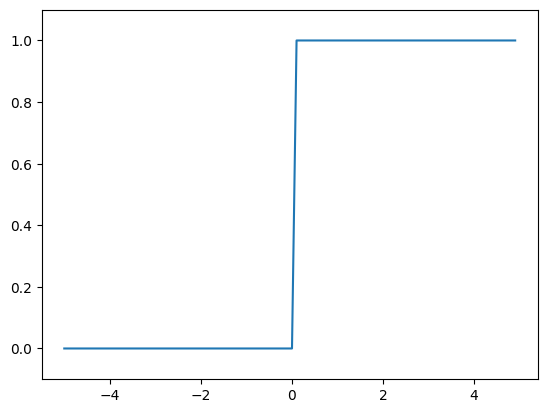

In [19]:
import numpy as np
import matplotlib.pylab as plt


def step_function(x):
    return np.array(x > 0, dtype=int)

X = np.arange(-5.0, 5.0, 0.1)
Y = step_function(X)
plt.plot(X, Y)
plt.ylim(-0.1, 1.1)  # 図で描画するy軸の範囲を指定
plt.show()

### 原論文→実装の対応を体感（しきい値素子）

McCulloch & Pitts [1] や Rosenblatt [2] の文脈では、「重み付き和がしきい値を超えたら発火（=1）、そうでなければ0」という **しきい値素子** が中心です。
ここでは、今描いたステップ関数 `step_function` をそのまま使って、論理ゲート（AND/OR）やパーセプトロン的な判定が **同じ数式** で書けることを確認します。

### 深さで勾配分布はどう変わる？（sigmoid vs ReLU）

ここでは「層を深くすると勾配の分布がどう変わるか」を、ランダムな多層ネットで疑似的に観察します。
RHW(1986) [6] が示すように、逆伝播では各層で局所導関数が掛け合わさるため、活性化関数の性質が勾配スケールに直結します。

**実験（簡略化した設定）**
- 幅 $n$ の全結合層を $L$ 層重ね、$z^{(l)}=\phi(a^{(l)})$（$\phi$ は sigmoid / ReLU）
- ランダム入力 $z^{(0)}$ とランダム重み $W^{(l)}$ で前向きを計算
- 出力側の勾配をランダムに与えて、逆伝播で $\partial L/\partial z^{(0)}$ を計算
- 深さ $L$ を変えたときの $\log_{10}(|\partial L/\partial z^{(0)}|)$ の分布（中央値・分位点）をプロット

※ データや学習はしていません（“初期化された深いネットで勾配がどうスケールしがちか”を見るための可視化です）。

In [20]:
import numpy as np

def perceptron(x, w, b):
    # Rosenblatt型の線形判別 + しきい値（ステップ）
    # y = 1[ w·x + b > 0 ]
    return (np.dot(w, x) + b > 0).astype(int)

# 2入力の論理ゲート（入力は {0,1}^2）
X = np.array([[0,0],[0,1],[1,0],[1,1]])

# OR: w=[1,1], b=-0.5 だと 0,0 だけが負になる
w_or = np.array([1.0, 1.0])
b_or = -0.5
y_or = np.array([perceptron(x, w_or, b_or) for x in X])

# AND: w=[1,1], b=-1.5 だと 1,1 のときだけ正になる
w_and = np.array([1.0, 1.0])
b_and = -1.5
y_and = np.array([perceptron(x, w_and, b_and) for x in X])

print('X:\n', X)
print('OR :', y_or)
print('AND:', y_and)

X:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
OR : [0 1 1 1]
AND: [0 0 0 1]


# ch03/sigmoid.py

## シグモイド関数（sigmoid）の数学的な解説

**定義（ロジスティック関数）**
$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

**値域と極限**
- 値域は $\sigma(x)\in(0,1)$（どんな $x$ でも厳密に0/1にはなりません）。
- $x\to -\infty$ で $\sigma(x)\to 0$、$x\to +\infty$ で $\sigma(x)\to 1$。

**導関数（誤差逆伝播で決定的に重要）**
$$
\sigma'(x)=\sigma(x)\,\bigl(1-\sigma(x)\bigr)
$$
- これにより、層をまたいで微分（連鎖律）を適用する計算が可能になります。RHW(1986) は、内部表現を学習するために誤差を逆向きに伝播させる（back-propagation）枠組みを示し、そこで微分可能な非線形が中心的に使われます [6]。

**飽和と勾配消失（シグモイドの典型的な弱点）**
- $\sigma'(x)$ の最大値は $x=0$ のとき $1/4$。
- $|x|$ が大きいと $\sigma(x)$ が0または1に“飽和”して $\sigma'(x)\approx 0$ になり、層を重ねたときに勾配が小さくなりやすい（学習が進みにくくなる）要因になります。

**「ステップ関数の滑らかな近似」としての見方**
傾きを $a>0$ とした
$$
\sigma_a(x)=\frac{1}{1+e^{-ax}}
$$
は $a$ が大きいほど切り替わりが急になり、$a\to\infty$ でステップ関数に近づきます。

**原論文との対応（ロジスティック曲線）**
- ロジスティック曲線は人口増加の研究などで現れ、Verhulst によって論じられています [3]。ニューラルネットでは、しきい値の“硬い”切り替え（ステップ）を、微分可能な“滑らかな”切り替えで置き換える意図で用いられます。

**実装上の注意**
- 多次元入力でも成分ごとに適用します（elementwise）。
- 指数関数を使うので、極端に大きい $|x|$ では数値的に不安定になり得ます（実務では入力のスケーリングや安定化実装を併用します）。

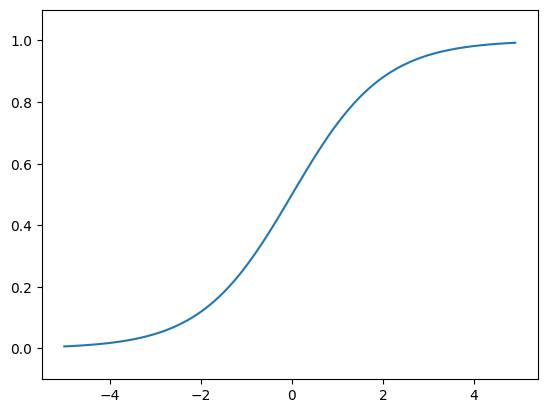

In [21]:
import numpy as np
import matplotlib.pylab as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X = np.arange(-5.0, 5.0, 0.1)
Y = sigmoid(X)
plt.plot(X, Y)
plt.ylim(-0.1, 1.1)
plt.show()


### 原論文→実装の対応を体感（RHW 1986: 微分可能性と勾配の大きさ）

RHW(1986) [6] の back-propagation は、誤差を逆向きに伝える際に連鎖律で導関数を掛け合わせます。
そこで「活性化関数の導関数がどのくらいの大きさになるか」が、そのまま勾配の流れやすさに効いてきます。
以下は、シグモイドの導関数 $\sigma'(x)=\sigma(x)(1-\sigma(x))$ が **飽和領域で極端に小さくなる** ことを、数値で確認するセルです。

max(sigmoid_grad) = 0.2499607455622195
sigmoid_grad at x=-10,0,10 = [4.53958077e-05 2.50000000e-01 4.53958077e-05]


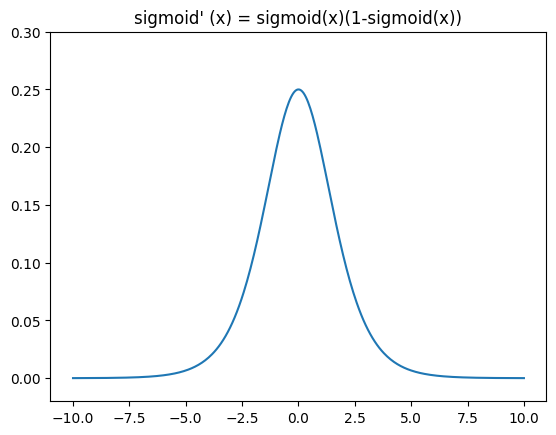

In [22]:
import numpy as np
import matplotlib.pylab as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

x = np.linspace(-10, 10, 400)
g = sigmoid_grad(x)

print('max(sigmoid_grad) =', g.max())
print('sigmoid_grad at x=-10,0,10 =', sigmoid_grad(np.array([-10.0, 0.0, 10.0])))

plt.plot(x, g)
plt.title("sigmoid' (x) = sigmoid(x)(1-sigmoid(x))")
plt.ylim(-0.02, 0.30)
plt.show()

# ch03/sig_step_compare.py

## ステップ関数とシグモイド関数の比較（数学的観点＋原論文の文脈）

どちらも「入力を $[0,1]$ 付近に写像する」単調増加関数であり、極限は似ています：
$$
\lim_{x\to-\infty}f(x)=0,\quad \lim_{x\to+\infty}f(x)=1
$$

ただし学習（微分・勾配）の観点では決定的な差があります。

**1) 連続性・微分可能性**
- ステップ関数は $x=0$ で不連続で、古典的な意味では微分が定義できません。
- シグモイドは滑らかで、どこでも微分可能です。RHW(1986) の back-propagation は誤差を逆向きに伝播させる際に連鎖律を繰り返し適用するため、こうした微分可能な非線形が実装上・理論上の基盤になります [6]。

**2) 「硬いしきい値」→「滑らかなしきい値」**
- McCulloch & Pitts は発火を all-or-none として理想化し、しきい値型の2値出力（論理素子）として議論します [1]。
- Rosenblatt のパーセプトロンも、重み付き和がしきい値を超えると反応する形式が中心で、これは実質的にステップ関数です [2]。
- これに対してシグモイドは、ロジスティック曲線（Verhulst）[3] を用いて「しきい値の切り替え」を滑らかにしたもの、とみなせます。

**3) 勾配の大きさ（学習のしやすさ）**
- シグモイドは導関数が $\sigma'(x)=\sigma(x)(1-\sigma(x))$ で、最大でも $1/4$、さらに飽和領域では $\approx 0$ になります。
- したがって層を深くすると、逆伝播で掛け合わされる微小な係数が増え、勾配が小さくなりやすい（学習が進みにくい）という直観につながります。

**4) その後の代表例：ReLU**
この「飽和して勾配が小さくなりやすい」問題に対して、後の研究では ReLU のような（少なくとも正の領域で）非飽和な活性化が広く使われるようになります [5]。

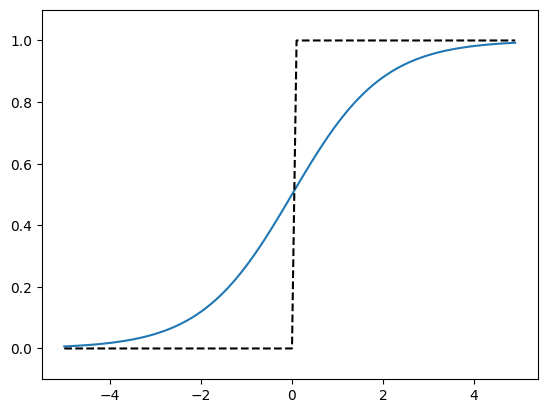

In [23]:
import numpy as np
import matplotlib.pylab as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(x)
y2 = step_function(x)

plt.plot(x, y1)
plt.plot(x, y2, 'k--')
plt.ylim(-0.1, 1.1) #図で描画するy軸の範囲を指定
plt.show()

# ch03/relu.py

## ReLU（Rectified Linear Unit）の数学的な解説

**定義**
$$
\operatorname{ReLU}(x)=\max(0,x)
$$

**導関数（サブグラディエント）**
$$
\operatorname{ReLU}'(x)=\begin{cases}
0 & (x<0)\\
1 & (x>0)
\end{cases}
$$
- $x=0$ では厳密には微分不可ですが、実装では $0$ などのサブグラディエントを用います。

**性質（学習への影響）**
- $x>0$ では勾配が $1$ のため、シグモイドのように正側で飽和して勾配が小さくなる現象が起きにくいです。
- $x<0$ では出力も勾配も $0$ になり、活性が疎（スパース）になりやすい一方、重み更新が止まって“死んだReLU（dying ReLU）”になることがあります。

**原論文との対応**
- ReLU を用いた学習上の利点（特に勾配が流れやすいこと、スパースな表現になりやすいこと）については、Nair & Hinton が RBM の文脈で整理しています [5]。

### 原論文→実装の対応を体感（Nair & Hinton 2010: 勾配が「流れる」領域が広い）

Nair & Hinton (2010) [5] は、ReLU を使うと（少なくとも $a>0$ の領域で）飽和しにくく、学習が進みやすいことを議論します。
この主張を「逆伝播で掛かる局所勾配 $\partial y/\partial a$ の分布」という形で、シグモイドとReLUで比較します。

- 前活性（pre-activation）$a$ をランダムに生成し、局所勾配 $g(a)=\partial y/\partial a$ を計算
- シグモイド： $g(a)=\sigma(a)(1-\sigma(a))$（最大でも $1/4$、飽和でほぼ0）
- ReLU： $g(a)=\mathbf{1}[a>0]$（正側は1、負側は0）

次のセルでは、(1) ヒストグラム、(2) “ほぼ0” の割合、を見て違いを定量化します。

sigmoid: mean grad = 0.15130356781007243  frac(|g|<eps)= 0.00056
ReLU   : mean grad = 0.49991  frac(|g|<eps)= 0.50009


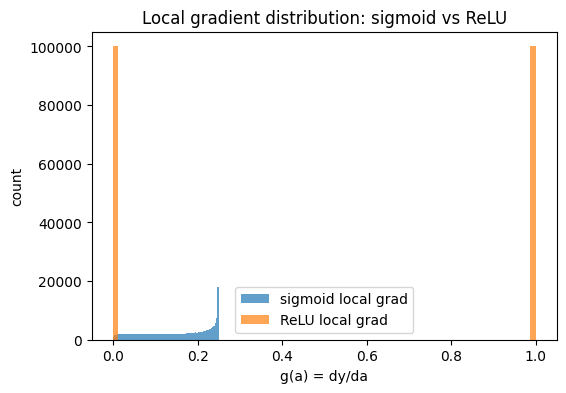

In [24]:
import numpy as np
import matplotlib.pylab as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def local_grad_sigmoid(a):
    s = sigmoid(a)
    return s * (1 - s)

def local_grad_relu(a):
    return (a > 0).astype(float)

rng = np.random.default_rng(0)
a = rng.normal(loc=0.0, scale=2.0, size=200000)  # 前活性 a の分布（例）

g_sig = local_grad_sigmoid(a)
g_relu = local_grad_relu(a)

eps = 1e-3
print('sigmoid: mean grad =', float(g_sig.mean()), ' frac(|g|<eps)=', float(np.mean(np.abs(g_sig) < eps)))
print('ReLU   : mean grad =', float(g_relu.mean()), ' frac(|g|<eps)=', float(np.mean(np.abs(g_relu) < eps)))

plt.figure(figsize=(6,4))
plt.hist(g_sig, bins=80, alpha=0.7, label="sigmoid local grad")
plt.hist(g_relu, bins=80, alpha=0.7, label="ReLU local grad")
plt.title("Local gradient distribution: sigmoid vs ReLU")
plt.xlabel("g(a) = dy/da")
plt.ylabel("count")
plt.legend()
plt.show()

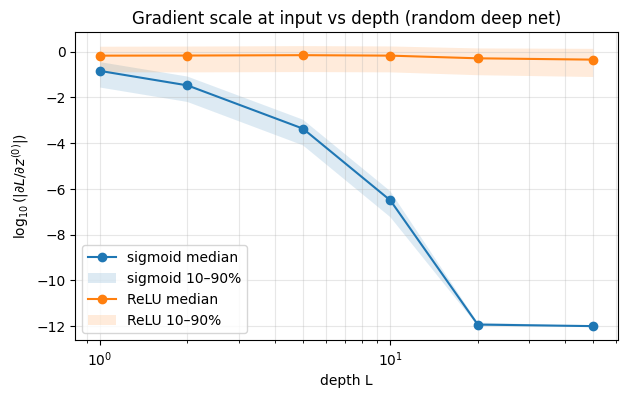

In [25]:
import numpy as np
import matplotlib.pylab as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def grad_sigmoid_from_output(z):
    # z = sigmoid(a) なので、da 側の局所勾配は z(1-z)
    return z * (1 - z)

def relu(a):
    return np.maximum(0.0, a)

def grad_relu(a):
    return (a > 0).astype(a.dtype)

def simulate_grad_log10(activation, depth_list, n=256, batch=256, seed=0):
    rng = np.random.default_rng(seed)
    z0 = rng.normal(size=(batch, n)).astype(np.float64)
    results = {}
    for L in depth_list:
        if activation == 'sigmoid':
            w_scale = np.sqrt(1.0 / n)  # Xavier 的（目安）
        elif activation == 'relu':
            w_scale = np.sqrt(2.0 / n)  # He 的（目安）
        else:
            raise ValueError('activation must be sigmoid or relu')

        W = [rng.normal(scale=w_scale, size=(n, n)) for _ in range(L)]
        a_list = []
        z_list = [z0]
        # forward
        z = z0
        for l in range(L):
            a = z @ W[l].T
            a_list.append(a)
            if activation == 'sigmoid':
                z = sigmoid(a)
            else:
                z = relu(a)
            z_list.append(z)

        # backward: 出力側の勾配をランダムに与える（形状合わせ）
        dz = rng.normal(size=z.shape)
        for l in reversed(range(L)):
            if activation == 'sigmoid':
                da = dz * grad_sigmoid_from_output(z_list[l+1])
            else:
                da = dz * grad_relu(a_list[l])
            dz = da @ W[l]  # dz_{l} = da_{l} W_{l}
        grad_input = dz
        log10_abs = np.log10(np.abs(grad_input) + 1e-12).ravel()
        results[L] = log10_abs
    return results

depths = [1, 2, 5, 10, 20, 50]
sig = simulate_grad_log10('sigmoid', depths, n=256, batch=256, seed=0)
rel = simulate_grad_log10('relu', depths, n=256, batch=256, seed=0)

def summarize(results, q=(10, 50, 90)):
    out = {k: np.percentile(v, q) for k, v in results.items()}
    return out

sig_q = summarize(sig)
rel_q = summarize(rel)

plt.figure(figsize=(7,4))
for label, qvals in [('sigmoid', sig_q), ('ReLU', rel_q)]:
    xs = np.array(sorted(qvals.keys()))
    ys = np.array([qvals[x] for x in xs])  # shape: (len(xs), 3)
    plt.plot(xs, ys[:,1], marker='o', label=f'{label} median')
    plt.fill_between(xs, ys[:,0], ys[:,2], alpha=0.15, label=f'{label} 10–90%')

plt.xscale('log')
plt.xlabel('depth L')
plt.ylabel(r'$\log_{10}(|\partial L/\partial z^{(0)}|)$')
plt.title('Gradient scale at input vs depth (random deep net)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

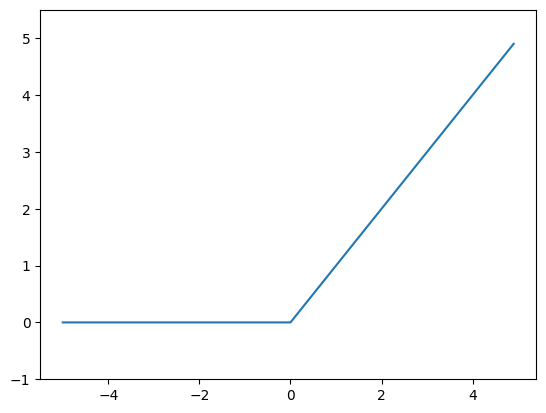

In [26]:
import numpy as np
import matplotlib.pylab as plt


def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1.0, 5.5)
plt.show()

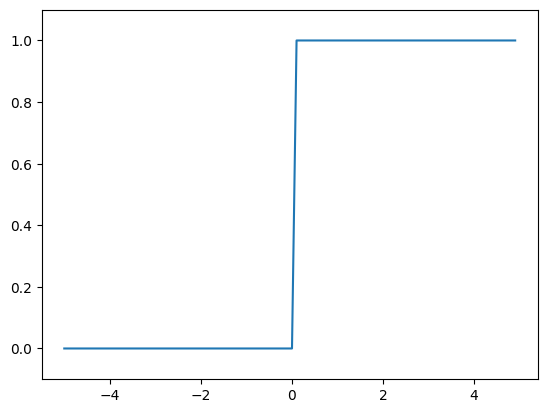

In [27]:
import numpy as np
import matplotlib.pylab as plt


def relu_grad(x):
    return (x > 0).astype(float)

x = np.arange(-5.0, 5.0, 0.1)
y = relu_grad(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

### 原論文→実装の対応を体感（RHW 1986: 連鎖律の「最小例」）

RHW(1986) [6] の肝は「誤差 $L$ を、各層の局所的な導関数を掛け合わせて前段へ伝播する」ことです。
ここでは *1ニューロンだけ* の最小例で、コードがそのまま連鎖律になっていることを確認します。

- 前向き： $a=\boldsymbol{w}^\top\boldsymbol{x}+b$、$y=\sigma(a)$
- 損失： $L=\tfrac12(y-t)^2$
- 逆向き： $\frac{\partial L}{\partial a}=(y-t)\,\sigma'(a)$、$\frac{\partial L}{\partial \boldsymbol{w}}=\frac{\partial L}{\partial a}\,\boldsymbol{x}$

次のセルで、手計算の勾配と数値微分が一致することを確かめます。

In [28]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def loss(w, b, x, t):
    a = np.dot(w, x) + b
    y = sigmoid(a)
    return 0.5 * (y - t) ** 2

def grad_analytic(w, b, x, t):
    a = np.dot(w, x) + b
    y = sigmoid(a)
    # dL/da = (y - t) * sigmoid'(a) = (y-t)*y*(1-y)
    dL_da = (y - t) * y * (1 - y)
    dL_dw = dL_da * x
    dL_db = dL_da
    return dL_dw, dL_db

def grad_numeric(w, b, x, t, eps=1e-6):
    g_w = np.zeros_like(w)
    for i in range(len(w)):
        w1 = w.copy(); w1[i] += eps
        w2 = w.copy(); w2[i] -= eps
        g_w[i] = (loss(w1, b, x, t) - loss(w2, b, x, t)) / (2 * eps)
    g_b = (loss(w, b + eps, x, t) - loss(w, b - eps, x, t)) / (2 * eps)
    return g_w, g_b

w = np.array([0.3, -0.5])
b = 0.1
x = np.array([1.0, 2.0])
t = 1.0

ga_w, ga_b = grad_analytic(w, b, x, t)
gn_w, gn_b = grad_numeric(w, b, x, t)

print('analytic dw:', ga_w, 'db:', ga_b)
print('numeric  dw:', gn_w, 'db:', gn_b)
print('max abs diff dw:', np.max(np.abs(ga_w - gn_w)), 'db:', abs(ga_b - gn_b))

analytic dw: [-0.14771599 -0.29543198] db: -0.14771598761591953
numeric  dw: [-0.14771599 -0.29543198] db: -0.1477159876084322
max abs diff dw: 1.497468815614411e-11 db: 7.487344078072056e-12


# ch03/mnist_show.py

In [29]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image


def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

img = x_train[0]
label = t_train[0]
print(label)  # 5

print(img.shape)  # (784,)
img = img.reshape(28, 28)  # 形状を元の画像サイズに変形
print(img.shape)  # (28, 28)

img_show(img)

5
(784,)
(28, 28)


# ch03/neuralnet_mnist.py

## ソフトマックス関数（softmax）の数学的な解説

このノートブック後半の推論コードでは、出力層で `softmax` を使っています。softmax は **ベクトル** $\boldsymbol{z}\in\mathbb{R}^K$ を確率分布へ写像する活性化関数です（シグモイド/ ReLU のような要素ごとの関数とは少し違います）。

**定義**
$$
\operatorname{softmax}(\boldsymbol{z})_i=\frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}\quad (i=1,\dots,K)
$$

**性質**
- 各成分は $\in(0,1)$ で、総和は $\sum_i \operatorname{softmax}(\boldsymbol{z})_i=1$（確率として解釈可能）。
- 定数シフトに不変：任意の $c$ について $\operatorname{softmax}(\boldsymbol{z})=\operatorname{softmax}(\boldsymbol{z}-c\mathbf{1})$。この性質を使い、実装では $\max_i z_i$ を引いて指数のオーバーフローを避けます。

**原論文との対応（確率分布への変換）**
- 出力層の「スコア」を確率分布に変換する方法として、Denker & LeCun は正規化された指数関数形（いわゆる softmax を含む）を用いる考え方を整理しています [4]。

### 原論文→実装の対応を体感（Denker & LeCun 1990: softmaxの安定化）

Denker & LeCun (1990) [4] の文脈では、ネットワークの出力を「確率として扱える形」に変換することがテーマになります。
softmax はまさにその変換ですが、実装では指数関数のオーバーフローが起き得るため、定数シフト不変性
$$
\operatorname{softmax}(\boldsymbol{z})=\operatorname{softmax}(\boldsymbol{z}-c\mathbf{1})
$$
を使って $c=\max_i z_i$ を引くのが定石です。
次のセルで、ナイーブ実装と安定化実装の違い（特に大きなスコアで破綻する）を確認します。

In [30]:
import numpy as np

def softmax_naive(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

def softmax_stable(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

z_small = np.array([1.0, 2.0, 3.0])
print('z_small softmax (naive) :', softmax_naive(z_small), 'sum=', softmax_naive(z_small).sum())
print('z_small softmax (stable):', softmax_stable(z_small), 'sum=', softmax_stable(z_small).sum())

# 大きなスコア：ナイーブだと overflow しやすい
z_big = np.array([1000.0, 1001.0, 1002.0])
try:
    print('z_big softmax (naive) :', softmax_naive(z_big))
except FloatingPointError as e:
    print('naive failed with:', e)
print('z_big softmax (stable):', softmax_stable(z_big), 'sum=', softmax_stable(z_big).sum())

z_small softmax (naive) : [0.09003057 0.24472847 0.66524096] sum= 1.0
z_small softmax (stable): [0.09003057 0.24472847 0.66524096] sum= 0.9999999999999999
z_big softmax (naive) : [nan nan nan]
z_big softmax (stable): [0.09003057 0.24472847 0.66524096] sum= 0.9999999999999999


/tmp/ipython-input-1726854747.py:4: RuntimeWarning: overflow encountered in exp
  exp_z = np.exp(z)
/tmp/ipython-input-1726854747.py:5: RuntimeWarning: invalid value encountered in divide
  return exp_z / np.sum(exp_z)


In [31]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test


def init_network():
    with open("../ch03/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y


x, t = get_data()
network = init_network()
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p= np.argmax(y) # 最も確率の高い要素のインデックスを取得
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

Accuracy:0.9352


# ch03/neuralnet_mnist_batch.py

In [32]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax


def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test


def init_network():
    with open("../ch03/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network


def predict(network, x):
    w1, w2, w3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, w1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, w2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, w3) + b3
    y = softmax(a3)

    return y


x, t = get_data()
network = init_network()

batch_size = 100 # バッチの数
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))


Accuracy:0.9352


# References

[1] Warren S. McCulloch and Walter Pitts. *A Logical Calculus of the Ideas Immanent in Nervous Activity*. Bulletin of Mathematical Biophysics, 5:115–133 (1943). （再録版が流通しています）

[2] Frank Rosenblatt. *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review, 65(6) (1958).

[3] P.-F. Verhulst. *Recherches mathématiques sur la loi d'accroissement de la population*. Nouveaux mémoires de l'Académie Royale des Sciences et Belles-Lettres de Bruxelles (1845).

[4] John S. Denker and Yann LeCun. *Transforming Neural-Net Output Levels to Probability Distributions*. NIPS (1990).

[5] Vinod Nair and Geoffrey E. Hinton. *Rectified Linear Units Improve Restricted Boltzmann Machines*. ICML (2010).

[6] David E. Rumelhart, Geoffrey E. Hinton, and Ronald J. Williams. *Learning representations by back-propagating errors*. Nature 323 (1986).